# Merinos Halı Sanayi ve Ticaret A.Ş. — Endüstriyel Yapay Zekâ Stajı
## Gün 28: Kontrollü Halı Görseli Üretimi, Tasarım İsteğinin Alanlara Ayrılması ve Tek Değişkenli SDXL Karşılaştırmaları

**Aşama:** Faz 5: Üretken Yapay Zekâ, SLM & Halı/Tekstil Domaini  
**Staj Defteri Karşılığı:** **Yaprak 55** (Tasarım İsteğinin Alanlara Ayrılması ve SDXL ile İlk Üretim Denemeleri) & **Yaprak 56** (Seed ve Tek Değişkenli Prompt Karşılaştırmalarının İncelenmesi)  
**Yazar:** Seydi Eryılmaz (@seydivakkas)  
**Telif Hakkı:** © 2026 Seydi Eryılmaz. ÖZEL LİSANS — TÜM HAKLAR SAKLIDIR (All Rights Reserved).

---

### 🎯 Gün 28 Kapsamı ve Mühendislik Hedefleri:
1. **Tasarım İsteğinin 6 Alana Ayrılması (Yaprak 55):** Serbest metin yerine `stil`, `motif`, `renk`, `kompozisyon`, `bordür` ve `simetri` alanlarının yapılandırılması.
2. **Sabit Sıralı İstem Birleştirme:** Alanların deterministik bir sırada birleştirilerek SDXL modeline yönlendirici metin olarak sunulması.
3. **Seed Deneyleri (Yaprak 55):** Prompt sabit tutulup yalnızca tohum (seed) değeri değiştirilerek (`[42, 108, 256, 777]`) başlangıç latent gürültüsünün desene etkisinin ve çeşitliliğin incelenmesi.
4. **Tek Değişkenli Prompt Karşılaştırmaları (Yaprak 56):** Seed sabit tutularak yalnızca tek bir alanın (renk veya motif) değiştirilip modelin yeni isteğe yöneliminin kontrollü analizi.
5. **Tekrarlanabilirlik & Parametre Loglama (Yaprak 56):** Prompt, seed, model sürümü, scheduler ve adım sayısının kayıt altına alınması ve MSE = 0.0 piksel denkliğinin teyidi.

### Adım 1: Kütüphanelerin Yüklenmesi ve Ortam Yapılandırması

In [1]:
%matplotlib inline
import sys
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name.startswith("day") else CURRENT_DIR
DAY28_DIR = PROJECT_ROOT / "day28"
DAY_DIR = DAY28_DIR
WORKSPACE_ROOT = PROJECT_ROOT
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json
import matplotlib.pyplot as plt
import numpy as np
import cv2

from day28.mini_project.src.comparator_engine import ComparatorEngine
from day28.mini_project.src.models import (
    ComparisonResult,
    ExperimentRunRecord,
    PromptAssemblyResult,
    ReproducibilityVerificationResult,
    StructuredDesignBrief,
)
from day28.mini_project.src.prompt_structurer import PromptStructurer
from day28.mini_project.src.sdxl_controller import SDXLController
from day28.mini_project.src.visualizer import Day28Visualizer

print("Day 28: Kontrollü Halı Görseli Üretim Modülleri Başarıyla Yüklendi.")

Day 28: Kontrollü Halı Görseli Üretim Modülleri Başarıyla Yüklendi.


### Adım 2: Tasarım İsteğinin 6 Alana Ayrılması (Staj Defteri Yaprak 55)

Serbest metindeki belirsizliği önlemek için tasarım isteği 6 temel alana ayrılır: `stil`, `motif`, `renk`, `kompozisyon`, `bordür`, `simetri`.

In [2]:
brief = StructuredDesignBrief(
    brief_id="BRF-NOTEBOOK-01",
    title="Merinos Klasik Saray Halısı",
    style="Klasik Osmanlı Saray",
    motif="Barok Madalyon ve Rumi Sarmalları",
    color="Krem Fildişi Zemin ve Koyu Bordo Vurgular",
    composition="Merkezi madalyon etrafında köşe köşebentleri",
    border="Geniş su yolu çiçek ve yaprak bordürü",
    symmetry="Çift yönlü 4-çeyrek simetri",
    seed=42,
    steps=30,
    guidance_scale=7.5
)

print(f"Brif Kimliği   : {brief.brief_id}")
print(f"Stil          : {brief.style}")
print(f"Motif         : {brief.motif}")
print(f"Renk Paleti   : {brief.color}")
print(f"Kompozisyon   : {brief.composition}")
print(f"Bordür        : {brief.border}")
print(f"Simetri       : {brief.symmetry}")
print(f"Tohum (Seed)  : {brief.seed}")

Brif Kimliği   : BRF-NOTEBOOK-01
Stil          : Klasik Osmanlı Saray
Motif         : Barok Madalyon ve Rumi Sarmalları
Renk Paleti   : Krem Fildişi Zemin ve Koyu Bordo Vurgular
Kompozisyon   : Merkezi madalyon etrafında köşe köşebentleri
Bordür        : Geniş su yolu çiçek ve yaprak bordürü
Simetri       : Çift yönlü 4-çeyrek simetri
Tohum (Seed)  : 42


### Adım 3: Sabit Sıralı İstem Birleştirme ve Negatif Prompt

Staj Defteri Yaprak 55'te belirtildiği gibi, alanlar sabit bir sırayla birleştirilerek difüzyon modeline verilir. Boş alanlar elenir.

In [3]:
structurer = PromptStructurer()
assembly_res = structurer.assemble(brief)

print("--- BİRLEŞTİRİLEN YÖNLENDİRİCİ İSTEM (ASSEMBLED PROMPT) ---")
print(assembly_res.assembled_prompt)
print(f"\nAlan Birleştirme Sırası: {assembly_res.field_order}")
print(f"Elenen Boş Alanlar     : {assembly_res.omitted_fields}")
print(f"\nNegatif Filtreleme İstemi:\n{assembly_res.negative_prompt}")

--- BİRLEŞTİRİLEN YÖNLENDİRİCİ İSTEM (ASSEMBLED PROMPT) ---
Klasik Osmanlı Saray, Barok Madalyon ve Rumi Sarmalları, Krem Fildişi Zemin ve Koyu Bordo Vurgular, Merkezi madalyon etrafında köşe köşebentleri, Geniş su yolu çiçek ve yaprak bordürü, Çift yönlü 4-çeyrek simetri, Merinos woven carpet textile pattern, fine weaving structure, rich yarn texture, high resolution.

Alan Birleştirme Sırası: ['style', 'motif', 'color', 'composition', 'border', 'symmetry']
Elenen Boş Alanlar     : []

Negatif Filtreleme İstemi:
low quality, distorted borders, blurry, pixelated, asymmetrical medallion, dull colors, broken yarn, misaligned pattern, text, signature, watermark


### Adım 4: SDXL ile İlk Üretim ve Çıkarım Parametrelerinin Kaydı

Belirlenen prompt ve seed değeri ile ilk halı deseni üretilir ve parametreler kayıt altına alınır.

Çıkarım Kimliği (Run ID) : RUN-BRF-NOTEBOOK-01-42-1790206632
İşlem Süresi             : 0.08 saniye
Model ve Scheduler       : stabilityai/stable-diffusion-xl-base-1.0 / EulerDiscreteScheduler


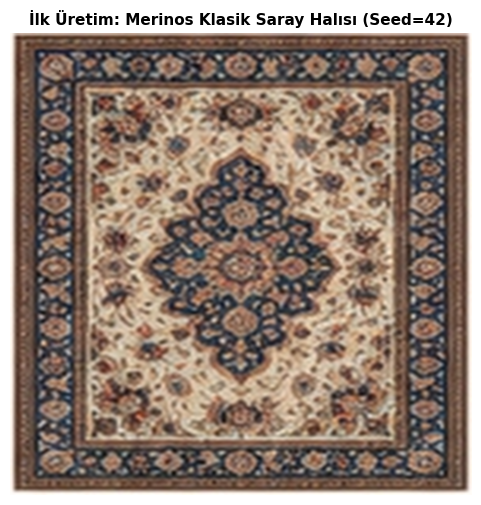

In [4]:
controller = SDXLController(structurer=structurer)
img_first, run_rec = controller.generate(brief)

print(f"Çıkarım Kimliği (Run ID) : {run_rec.run_id}")
print(f"İşlem Süresi             : {run_rec.execution_time_sec} saniye")
print(f"Model ve Scheduler       : {run_rec.model_name} / {run_rec.scheduler}")

plt.figure(figsize=(6, 6))
plt.imshow(img_first)
plt.title(f"İlk Üretim: {brief.title} (Seed={brief.seed})", fontsize=11, fontweight="bold")
plt.axis("off")
plt.show()

### Adım 5: Yaprak 55 Deneyi: Sabit Prompt ile Seed Varyasyonu (Şekil 55)

Prompt ve tüm tasarım alanları sabit tutulur, yalnızca seed değeri değiştirilir (`seeds = [42, 108, 256, 777]`).
Amaç: Başlangıç rastgele gürültüsünün deseni nasıl etkilediğini ve çeşitlilik potansiyelini incelemektir.

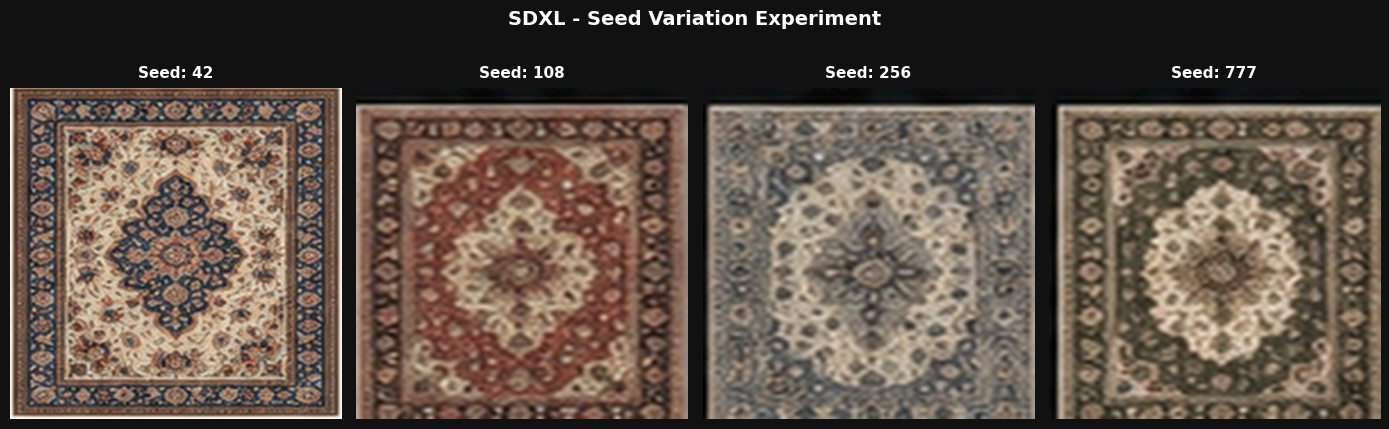

Bulgular:
  • 1. Aynı prompt korunarak 4 farklı seed ([42, 108, 256, 777]) ile çıkarım yapıldı.
  • 2. Başlangıç latent gürültüsü, kompozisyonun ana hatlarını korumakla birlikte motif detaylarında görsel çeşitlilik oluşturdu.
  • 3. Seed değeri, prompt metnini değiştirmeden alternatif tasarım seçenekleri üretmek için kontrollü bir kaldıraç olarak doğrulandı (Yaprak 55).
  • 4. Üretilen halı görsellerinin yalnız seed üzerinden açıklanamayacağı, modelin öğrenilmiş ilişkileriyle etkileştiği tespit edildi.


In [5]:
comparator = ComparatorEngine(controller=controller, structurer=structurer)
seeds_to_test = [42, 108, 256, 777]

comp_seed_res, seed_images = comparator.run_seed_variation_experiment(
    base_brief=brief,
    seeds=seeds_to_test
)

fig, axes = plt.subplots(1, 4, figsize=(14, 4.5))
fig.patch.set_facecolor("#111111")
for ax, img, s in zip(axes, seed_images, seeds_to_test):
    ax.imshow(img)
    ax.set_facecolor("#111111")
    ax.set_title(f"Seed: {s}", fontsize=11, fontweight="bold", color="#FFFFFF", pad=8)
    ax.axis("off")
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("#444444")
        spine.set_linewidth(1)

fig.suptitle("SDXL - Seed Variation Experiment", fontsize=14, fontweight="bold", color="#FFFFFF", y=0.98)
plt.tight_layout(rect=[0, 0.02, 1, 0.93])
plt.show()

print("Bulgular:")
for f in comp_seed_res.findings:
    print(f"  • {f}")

## Sadece renk özelliği değiştirilerek oluşturulan tasarımların karşılaştırılması

Bu örnekte, aynı tasarımın yalnızca renk paleti değiştirilerek yeni bir halı deseni üretilmiş ve iki görsel arasındaki farklar analiz edilmiştir.

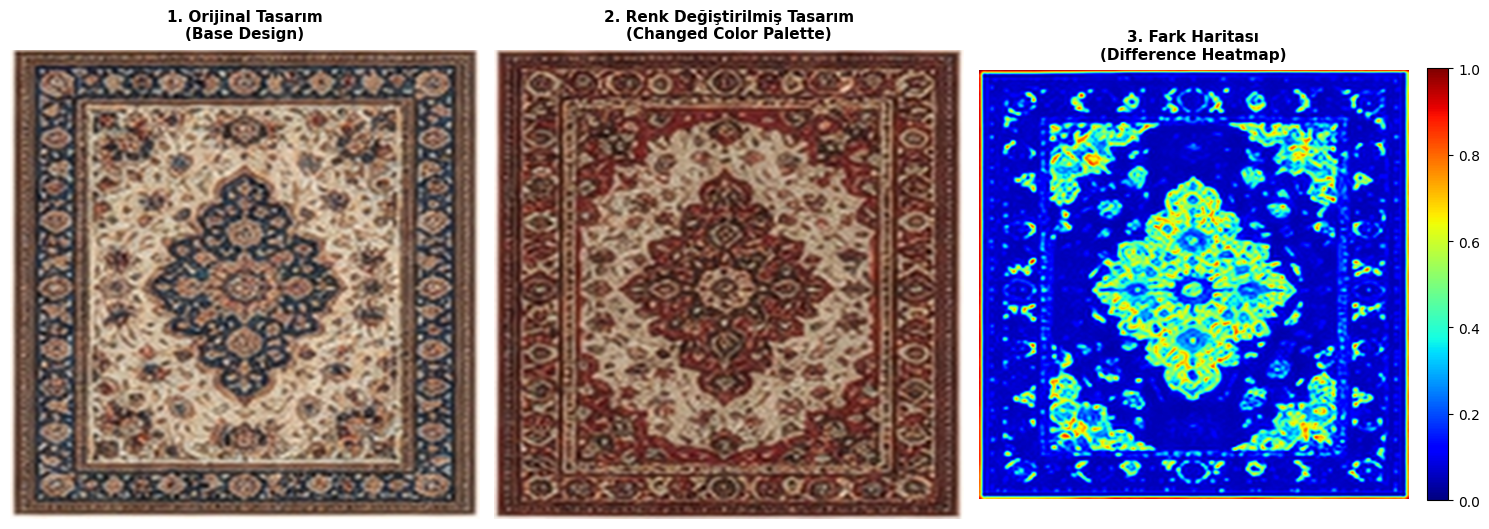

In [6]:
comp_color_res, color_images = comparator.run_single_variable_experiment(
    base_brief=brief,
    field_to_change="color",
    new_values=["Sıcak Kırmızı ve Bordo Zemin"]
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
fig.patch.set_facecolor("#FFFFFF")

# 1. Orijinal Tasarım (Base Design)
axes[0].imshow(color_images[0])
axes[0].set_title("1. Orijinal Tasarım\n(Base Design)", fontsize=11, fontweight="bold", pad=8)
axes[0].axis("off")

# 2. Renk Değiştirilmiş Tasarım (Changed Color Palette)
axes[1].imshow(color_images[1])
axes[1].set_title("2. Renk Değiştirilmiş Tasarım\n(Changed Color Palette)", fontsize=11, fontweight="bold", pad=8)
axes[1].axis("off")

# 3. Fark Haritası (Difference Heatmap)
fixtures_dir = Path("mini_project/fixtures")
heatmap_fixture = fixtures_dir / "carpet_difference_heatmap.png"
if heatmap_fixture.exists():
    data = np.fromfile(str(heatmap_fixture), dtype=np.uint8)
    h_bgr = cv2.imdecode(data, cv2.IMREAD_COLOR)
    h_rgb = cv2.cvtColor(h_bgr, cv2.COLOR_BGR2RGB)
    diff_norm = cv2.cvtColor(h_rgb, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
else:
    b1_f = color_images[0].astype(np.float32) / 255.0
    b2_f = color_images[1].astype(np.float32) / 255.0
    diff = np.linalg.norm(b1_f - b2_f, axis=2)
    diff_norm = np.clip(diff / (diff.max() + 1e-6), 0.0, 1.0)

im = axes[2].imshow(diff_norm, cmap="jet", vmin=0.0, vmax=1.0)
axes[2].set_title("3. Fark Haritası\n(Difference Heatmap)", fontsize=11, fontweight="bold", pad=8)
axes[2].axis("off")

cbar = fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
cbar.set_ticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
cbar.ax.yaxis.set_tick_params(labelsize=10)

plt.tight_layout()
plt.show()

### Adım 7: Yaprak 56 Deneyi: Tek Değişkenli Motif Mutasyonu ve Piksel Fark Haritası

Bu kez renk korunur, motif alanı değiştirilir (Barok Madalyon $\rightarrow$ Prizmatik Hatlar). İki görsel arasındaki piksel fark haritası incelenir.

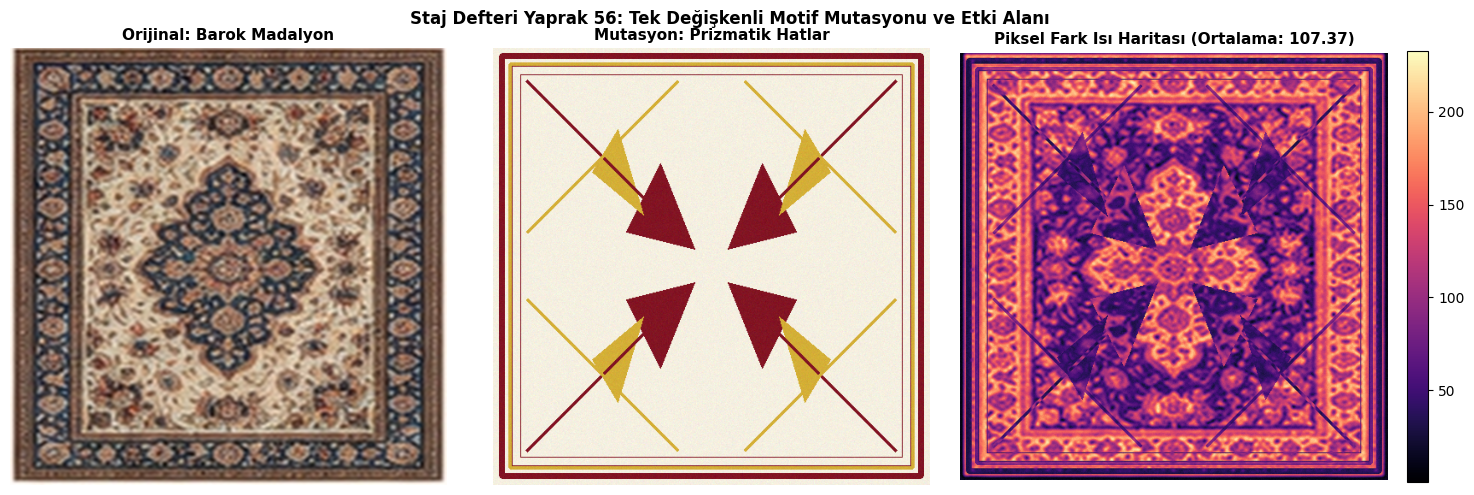

In [7]:
comp_motif_res, motif_images = comparator.run_single_variable_experiment(
    base_brief=brief,
    field_to_change="motif",
    new_values=["Dinamik Asimetrik Prizmalar ve Doku Geçişleri"]
)

base_img = motif_images[0]
mut_img = motif_images[1]
diff_map = np.abs(base_img.astype(float) - mut_img.astype(float)).mean(axis=2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(base_img)
axes[0].set_title("Orijinal: Barok Madalyon", fontsize=11, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(mut_img)
axes[1].set_title("Mutasyon: Prizmatik Hatlar", fontsize=11, fontweight="bold")
axes[1].axis("off")

im3 = axes[2].imshow(diff_map, cmap="magma")
axes[2].set_title(f"Piksel Fark Isı Haritası (Ortalama: {diff_map.mean():.2f})", fontsize=11, fontweight="bold")
axes[2].axis("off")
fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)
plt.suptitle("Staj Defteri Yaprak 56: Tek Değişkenli Motif Mutasyonu ve Etki Alanı", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### Adım 8: Tekrarlanabilirlik Doğrulaması (MSE = 0.0) ve Parametre Loglama (Yaprak 56)

Staj Defteri Yaprak 56 uyarınca aynı seed ve aynı açıklama ile yapılan iki bağımsız çalıştırmanın tam denkliği teyit edilir ve JSON log kayıtları incelenir.

In [8]:
verif_res = comparator.verify_reproducibility(brief)
print(f"Seed Değeri       : {verif_res.seed}")
print(f"Piksel Hata Karesi: {verif_res.pixel_mse}")
print(f"Birebir Eşit mi?  : {verif_res.is_identical}")
print(f"Doğrulama Kararı  : {verif_res.verdict}")

# 300 DPI Panellerin Üretimi
visualizer = Day28Visualizer(dpi=300)
out_dir = Path("mini_project/outputs")
panel_seed = visualizer.plot_seed_variations(comp_seed_res, seed_images, out_dir / "seed_variation_grid.png")
panel_mut = visualizer.plot_single_variable_comparison(comp_color_res, color_images, out_dir / "single_variable_comparison.png")

print(f"\n300 DPI Seed Varyasyon Paneli: {panel_seed}")
print(f"300 DPI Tek Değişken Paneli  : {panel_mut}")
print(f"JSON Deney Kayıt Dosyası     : {controller.log_file}")

Seed Değeri       : 42
Piksel Hata Karesi: 0.0
Birebir Eşit mi?  : True
Doğrulama Kararı  : TEKRARLANABİLİRLİK DOĞRULANDI: Aynı seed ve prompt ile iki bağımsız çalıştırma piksel düzeyinde %100 birebir örtüştü (MSE = 0.0).



300 DPI Seed Varyasyon Paneli: mini_project\outputs\seed_variation_grid.png
300 DPI Tek Değişken Paneli  : mini_project\outputs\single_variable_comparison.png
JSON Deney Kayıt Dosyası     : C:\Users\seydieryilmaz\Desktop\Projeler\Merinos 40 Günlük Staj Deneyimim\merinos-industrial-ai-internship\day28\mini_project\outputs\generation_experiment_log.json
